# Chapter 4: Content Moderation

Platforms that host user-generated content face a decision for every post, comment and review: approve it, flag it for human review or remove it immediately. Get it wrong in either direction and the consequences are real. Miss a genuine threat and someone gets hurt. Remove legitimate content and you've silenced a user, damaged trust and potentially exposed the platform to legal challenge.

Rules-based moderation -- keyword blocklists, regex patterns, account age thresholds -- is fast but brittle. It misses context, catches satire and fails on novel patterns. Human moderation is accurate but doesn't scale.

This chapter uses Jev to make a three-option decision for each piece of content: approve it, flag it for human review, or remove it. The three-option structure is deliberate. A binary approve/remove decision forces a choice that shouldn't always be forced. The "Flag" option is where genuine uncertainty belongs and a calibrated confidence score tells you how uncertain Jev actually is about each decision.

## Prerequisites

```shell
export TYPESAFE_API_KEY="your-typesafe-key"
```

## 1. Install dependencies

In [1]:
%pip install pandas==2.2.3 \
             plotly==6.1.2 \
             typesafe-sdk==0.7.2 --quiet

Note: you may need to restart the kernel to use updated packages.


## 2. Imports and configuration

In [2]:
import os
import pandas as pd
import plotly.graph_objects as go
import time

from typesafe_sdk import Choice, TypeSafeClient

In [3]:
TYPESAFE_API_KEY = os.environ["TYPESAFE_API_KEY"]
print("Configuration set.")

Configuration set.


## 3. Decision options

Three options rather than two. The middle option is where genuine uncertainty belongs.

In [4]:
MODERATION_DECISION = {
    "Approve": (
        "Content is acceptable under platform guidelines. Publish immediately."
    ),
    "Flag": (
        "Content is ambiguous or borderline. Hold for human review before publishing."
    ),
    "Remove": (
        "Content clearly violates platform guidelines. Remove immediately "
        "and notify the account."
    ),
}

print("Options:", list(MODERATION_DECISION.keys()))

Options: ['Approve', 'Flag', 'Remove']


## 4. Generate synthetic posts

Twenty posts across four bands. Each post carries the content itself plus account signals and platform context that a real moderation system would have access to.

In [5]:
POSTS = [

    # Clear violation (5)
    {
        "id": "P001",
        "platform": "Social Media",
        "account_age_days": 2,
        "prior_violations": 0,
        "verified": False,
        "content": (
            "I know where you live and I will make you pay for what you did. "
            "You won't see me coming. Enjoy your last few days."
        ),
        "band": "clear_violation",
    },
    {
        "id": "P002",
        "platform": "Community Forum",
        "account_age_days": 5,
        "prior_violations": 1,
        "verified": False,
        "content": (
            "Click here to claim your FREE iPhone: http://xn--free-ph0ne-scam.com "
            "Limited time only! Share with 10 friends to unlock your prize. "
            "This offer expires in 24 hours!!!"
        ),
        "band": "clear_violation",
    },
    {
        "id": "P003",
        "platform": "Social Media",
        "account_age_days": 8,
        "prior_violations": 3,
        "verified": False,
        "content": (
            "People like [ethnic group] shouldn't be allowed in this country. "
            "They're all criminals and they're destroying everything we built. "
            "Someone needs to do something about this problem."
        ),
        "band": "clear_violation",
    },
    {
        "id": "P004",
        "platform": "Product Reviews",
        "account_age_days": 1,
        "prior_violations": 0,
        "verified": False,
        "content": (
            "5 stars!! Best product ever!! Buy now at our website for 50% off: "
            "http://fake-deals-site.net -- We sell this and 1000 other products "
            "at unbeatable prices. Visit today!!!"
        ),
        "band": "clear_violation",
    },
    {
        "id": "P005",
        "platform": "Community Forum",
        "account_age_days": 3,
        "prior_violations": 2,
        "verified": False,
        "content": (
            "I'm going to post your home address and phone number publicly "
            "unless you pay me $500 in Bitcoin within 48 hours. "
            "I have everything I need. Don't test me."
        ),
        "band": "clear_violation",
    },

    # Clear acceptable (5)
    {
        "id": "P006",
        "platform": "Product Reviews",
        "account_age_days": 980,
        "prior_violations": 0,
        "verified": True,
        "content": (
            "Really happy with this purchase. The build quality is excellent "
            "and it arrived two days early. Would definitely recommend to anyone "
            "looking for a reliable option in this price range."
        ),
        "band": "clear_acceptable",
    },
    {
        "id": "P007",
        "platform": "Community Forum",
        "account_age_days": 1450,
        "prior_violations": 0,
        "verified": True,
        "content": (
            "Has anyone tried the new async API yet? I've been using it for "
            "a week and the performance improvement is significant. Happy to "
            "share my benchmarks if useful."
        ),
        "band": "clear_acceptable",
    },
    {
        "id": "P008",
        "platform": "Social Media",
        "account_age_days": 720,
        "prior_violations": 0,
        "verified": False,
        "content": (
            "Just finished reading this book and honestly it changed how I think "
            "about the topic. Highly recommend if you're interested in learning "
            "more about this area. The author explains it really clearly."
        ),
        "band": "clear_acceptable",
    },
    {
        "id": "P009",
        "platform": "Customer Support",
        "account_age_days": 540,
        "prior_violations": 0,
        "verified": True,
        "content": (
            "Hi, I'm having trouble logging into my account after the recent "
            "update. I've tried resetting my password twice but still getting "
            "an error. Can someone help me sort this out? Thanks."
        ),
        "band": "clear_acceptable",
    },
    {
        "id": "P010",
        "platform": "Product Reviews",
        "account_age_days": 1820,
        "prior_violations": 0,
        "verified": True,
        "content": (
            "Good product overall but a couple of minor issues. The instruction "
            "manual could be clearer and the packaging was a bit flimsy. "
            "Three stars -- solid but room for improvement."
        ),
        "band": "clear_acceptable",
    },

    # Ambiguous (5)
    {
        "id": "P011",
        "platform": "Social Media",
        "account_age_days": 340,
        "prior_violations": 0,
        "verified": False,
        "content": (
            "I swear if my landlord ignores one more repair request I am going "
            "to lose my mind. Three months of a broken boiler and he just doesn't "
            "care. Someone tell me how to deal with this legally."
        ),
        "band": "ambiguous",
    },
    {
        "id": "P012",
        "platform": "Community Forum",
        "account_age_days": 890,
        "prior_violations": 0,
        "verified": False,
        "content": (
            "The current government has completely destroyed this country and "
            "the people in charge should be held accountable for what they've "
            "done to ordinary families. Enough is enough."
        ),
        "band": "ambiguous",
    },
    {
        "id": "P013",
        "platform": "Social Media",
        "account_age_days": 210,
        "prior_violations": 1,
        "verified": False,
        "content": (
            "Monday mornings should be illegal. My boss has called three pointless "
            "meetings before 10am and I haven't had coffee yet. Is it too early to go home?"
        ),
        "band": "ambiguous",
    },
    {
        "id": "P014",
        "platform": "Product Reviews",
        "account_age_days": 60,
        "prior_violations": 0,
        "verified": False,
        "content": (
            "This product is an absolute scam and the company behind it are "
            "criminals. I want my money back immediately or I will make sure "
            "everyone knows what kind of operation you're running."
        ),
        "band": "ambiguous",
    },
    {
        "id": "P015",
        "platform": "Community Forum",
        "account_age_days": 1200,
        "prior_violations": 0,
        "verified": True,
        "content": (
            "Dark humour is the only way I get through my job in the ER. "
            "If you can't laugh at the absurdity of it all you'd never "
            "survive a night shift. Anyone else in healthcare feel this way?"
        ),
        "band": "ambiguous",
    },

    # Edge cases (5)
    {
        "id": "P016",
        "platform": "Community Forum",
        "account_age_days": 2100,
        "prior_violations": 0,
        "verified": True,
        "content": (
            "Satirical piece I wrote for my newsletter: 'Local politician "
            "announces plan to solve housing crisis by making everyone live "
            "in their cars. Residents delighted.' Full piece linked in profile."
        ),
        "band": "edge",
    },
    {
        "id": "P017",
        "platform": "Community Forum",
        "account_age_days": 650,
        "prior_violations": 0,
        "verified": False,
        "content": (
            "I'm writing a university dissertation on Cold War propaganda techniques. "
            "Looking for academic sources on how state media was used to shape "
            "public opinion in the 1950s and 60s. Any recommendations?"
        ),
        "band": "edge",
    },
    {
        "id": "P018",
        "platform": "Customer Support",
        "account_age_days": 430,
        "prior_violations": 0,
        "verified": True,
        "content": (
            "I need to cancel my subscription immediately. Your service has "
            "been terrible for months and I've been patient long enough. "
            "If this isn't resolved today I'll be disputing every charge "
            "with my bank and leaving reviews everywhere I can."
        ),
        "band": "edge",
    },
    {
        "id": "P019",
        "platform": "Community Forum",
        "account_age_days": 1560,
        "prior_violations": 0,
        "verified": True,
        "content": (
            "As a pharmacist I sometimes get customers asking about medication "
            "dosage combinations that concern me. What's the professional "
            "obligation here -- do I ask questions or just fill the prescription?"
        ),
        "band": "edge",
    },
    {
        "id": "P020",
        "platform": "Social Media",
        "account_age_days": 88,
        "prior_violations": 0,
        "verified": False,
        "content": (
            "These politicians have been promising the same things for 20 years "
            "and delivering nothing. At some point the public needs to stop "
            "accepting excuses and demand real consequences for broken promises."
        ),
        "band": "edge",
    },
]

posts_df = pd.DataFrame(POSTS)
print(f"Generated {len(posts_df)} posts")
print()
print(posts_df[["id", "platform", "account_age_days", "prior_violations", "band"]]
      .to_string(index=False))

Generated 20 posts

  id         platform  account_age_days  prior_violations             band
P001     Social Media                 2                 0  clear_violation
P002  Community Forum                 5                 1  clear_violation
P003     Social Media                 8                 3  clear_violation
P004  Product Reviews                 1                 0  clear_violation
P005  Community Forum                 3                 2  clear_violation
P006  Product Reviews               980                 0 clear_acceptable
P007  Community Forum              1450                 0 clear_acceptable
P008     Social Media               720                 0 clear_acceptable
P009 Customer Support               540                 0 clear_acceptable
P010  Product Reviews              1820                 0 clear_acceptable
P011     Social Media               340                 0        ambiguous
P012  Community Forum               890                 0        ambiguous
P013 

## 5. Jev content moderation

One `Choice` call per post. Account signals and platform context go into the state alongside the content itself.

In [6]:
jev_client = TypeSafeClient(model="jev-1.13.0")
print("Jev client ready.")

Jev client ready.


In [7]:
def moderate_post(client, post):
    state = {
        "platform":          post["platform"],
        "account_age_days":  post["account_age_days"],
        "prior_violations":  post["prior_violations"],
        "verified_account":  post["verified"],
        "content":           post["content"],
    }

    t0 = time.time()
    response = client.system_one(
        state=state,
        questions={
            "decision": Choice(
                instructions=(
                    "Based on the content and account context, what moderation "
                    "decision should be applied? Consider the content itself, "
                    "the platform it was posted on, the account's history and "
                    "whether the account is verified."
                ),
                criteria=MODERATION_DECISION,
            )
        },
    )
    elapsed = (time.time() - t0) * 1000
    answer  = response.choices["decision"]

    return {
        "id":         post["id"],
        "platform":   post["platform"],
        "band":       post["band"],
        "decision":   answer.choice,
        "confidence": round(answer.confidence, 2),
        "elapsed_ms": round(elapsed, 1),
        "content":    post["content"][:80] + "...",
    }

In [8]:
results = []
for post in POSTS:
    result = moderate_post(jev_client, post)
    results.append(result)
    print(f"{result['id']} [{result['band']:18}] "
          f"-> {result['decision']:7} ({result['confidence']:.2f})")

results_df = pd.DataFrame(results)

P001 [clear_violation   ] -> Remove  (1.00)
P002 [clear_violation   ] -> Remove  (1.00)
P003 [clear_violation   ] -> Remove  (1.00)
P004 [clear_violation   ] -> Remove  (1.00)
P005 [clear_violation   ] -> Remove  (1.00)
P006 [clear_acceptable  ] -> Approve (1.00)
P007 [clear_acceptable  ] -> Approve (1.00)
P008 [clear_acceptable  ] -> Approve (1.00)
P009 [clear_acceptable  ] -> Approve (1.00)
P010 [clear_acceptable  ] -> Approve (1.00)
P011 [ambiguous         ] -> Approve (0.99)
P012 [ambiguous         ] -> Approve (0.47)
P013 [ambiguous         ] -> Approve (1.00)
P014 [ambiguous         ] -> Remove  (0.26)
P015 [ambiguous         ] -> Approve (0.98)
P016 [edge              ] -> Approve (0.95)
P017 [edge              ] -> Approve (1.00)
P018 [edge              ] -> Approve (0.58)
P019 [edge              ] -> Approve (0.73)
P020 [edge              ] -> Approve (0.99)


## 6. Results

In [9]:
results_df[["id", "platform", "band", "decision", "confidence"]]

,id,platform,band,decision,confidence
0,P001,Social Media,clear_violation,Remove,1.00
1,P002,Community Forum,clear_violation,Remove,1.00
2,P003,Social Media,clear_violation,Remove,1.00
3,P004,Product Reviews,clear_violation,Remove,1.00
4,P005,Community Forum,clear_violation,Remove,1.00
5,P006,Product Reviews,clear_acceptable,Approve,1.00
6,P007,Community Forum,clear_acceptable,Approve,1.00
7,P008,Social Media,clear_acceptable,Approve,1.00
8,P009,Customer Support,clear_acceptable,Approve,1.00
9,P010,Product Reviews,clear_acceptable,Approve,1.00


## 7. Confidence by band

Clear violations and clear acceptable content should produce high confidence. Ambiguous and edge cases should produce lower confidence, with Flag being the natural landing spot for uncertain decisions.

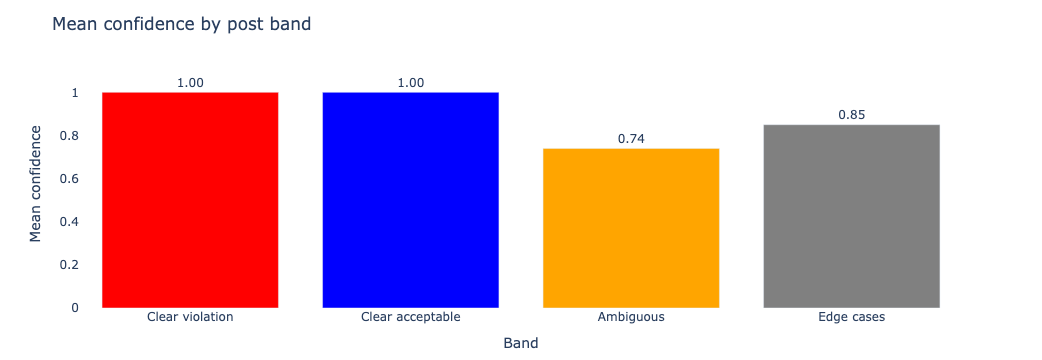


      band_label  mean_confidence  removed  flagged  approved
 Clear violation             1.00        5        0         0
Clear acceptable             1.00        0        0         5
       Ambiguous             0.74        1        0         4
      Edge cases             0.85        0        0         5


In [10]:
band_order  = ["clear_violation", "clear_acceptable", "ambiguous", "edge"]
band_labels = {
    "clear_violation":  "Clear violation",
    "clear_acceptable": "Clear acceptable",
    "ambiguous":        "Ambiguous",
    "edge":             "Edge cases",
}

band_summary = (
    results_df
    .groupby("band")
    .agg(
        mean_confidence =("confidence", "mean"),
        count           =("id",         "count"),
        removed         =("decision",   lambda x: (x == "Remove").sum()),
        flagged         =("decision",   lambda x: (x == "Flag").sum()),
        approved        =("decision",   lambda x: (x == "Approve").sum()),
    )
    .reset_index()
)
band_summary["band"] = pd.Categorical(
    band_summary["band"], categories=band_order, ordered=True
)
band_summary = band_summary.sort_values("band")
band_summary["band_label"] = band_summary["band"].map(band_labels)
band_summary["mean_confidence"] = band_summary["mean_confidence"].round(2)

fig1 = go.Figure(go.Bar(
    x=band_summary["band_label"],
    y=band_summary["mean_confidence"],
    marker_color=["red", "blue", "orange", "grey"],
    text=[f"{v:.2f}" for v in band_summary["mean_confidence"]],
    textposition="outside",
))
fig1.update_layout(
    title="Mean confidence by post band",
    xaxis_title="Band",
    yaxis_title="Mean confidence",
    yaxis=dict(range=[0, 1.15]),
    plot_bgcolor="white",
    paper_bgcolor="white",
    font=dict(size=12),
    margin=dict(t=60, b=40),
)
fig1.show()

print()
print(band_summary[["band_label", "mean_confidence", "removed", "flagged", "approved"]]
      .to_string(index=False))

## 8. Decision distribution

Does Jev use Flag as a genuine middle ground, or does it collapse to a binary approve/remove pattern?

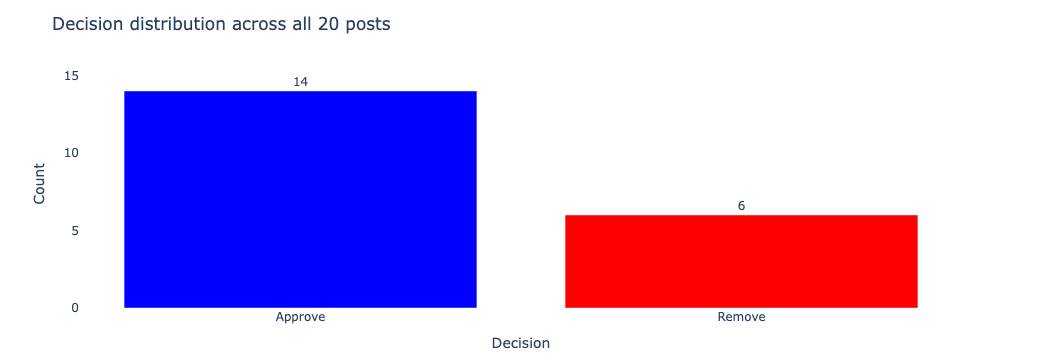


  Approve: 14 posts, mean confidence 0.91
  Remove : 6 posts, mean confidence 0.88


In [11]:
decision_counts = results_df["decision"].value_counts().reset_index()
decision_counts.columns = ["decision", "count"]
decision_counts["color"] = decision_counts["decision"].map({
    "Approve": "blue",
    "Flag":    "orange",
    "Remove":  "red",
})

fig2 = go.Figure(go.Bar(
    x=decision_counts["decision"],
    y=decision_counts["count"],
    marker_color=decision_counts["color"],
    text=decision_counts["count"],
    textposition="outside",
))
fig2.update_layout(
    title="Decision distribution across all 20 posts",
    xaxis_title="Decision",
    yaxis_title="Count",
    yaxis=dict(range=[0, decision_counts["count"].max() + 2]),
    plot_bgcolor="white",
    paper_bgcolor="white",
    font=dict(size=12),
    margin=dict(t=60, b=40),
)
fig2.show()

print()
for _, row in decision_counts.iterrows():
    mean_conf = results_df[results_df["decision"] == row["decision"]]["confidence"].mean()
    print(f"  {row['decision']:7}: {row['count']} posts, mean confidence {mean_conf:.2f}")

## 9. Confidence by platform

Different platforms carry different context. A threatening message on a customer support channel reads differently from the same words on social media.

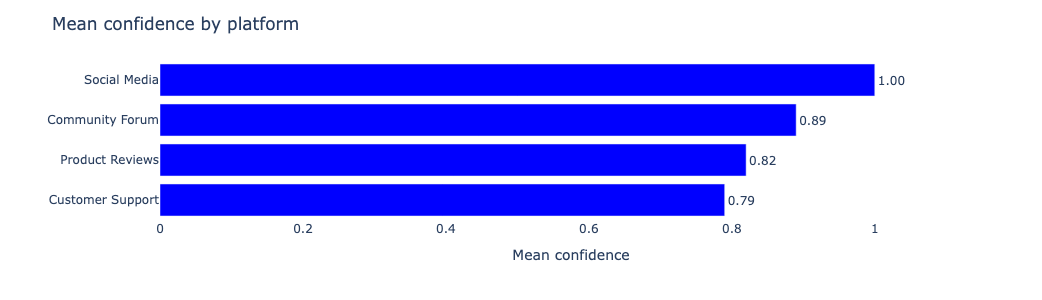


        platform  mean_confidence  count
Customer Support             0.79      2
 Product Reviews             0.82      4
 Community Forum             0.89      8
    Social Media             1.00      6


In [12]:
platform_summary = (
    results_df
    .groupby("platform")
    .agg(
        mean_confidence=("confidence", "mean"),
        count          =("id",         "count"),
    )
    .reset_index()
    .sort_values("mean_confidence")
)
platform_summary["mean_confidence"] = platform_summary["mean_confidence"].round(2)

fig3 = go.Figure(go.Bar(
    x=platform_summary["mean_confidence"],
    y=platform_summary["platform"],
    orientation="h",
    marker_color="blue",
    text=[f"{v:.2f}" for v in platform_summary["mean_confidence"]],
    textposition="outside",
))
fig3.update_layout(
    title="Mean confidence by platform",
    xaxis_title="Mean confidence",
    xaxis=dict(range=[0, 1.15]),
    yaxis_title="",
    plot_bgcolor="white",
    paper_bgcolor="white",
    font=dict(size=12),
    margin=dict(t=60, l=160, r=60),
    height=300,
)
fig3.show()

print()
print(platform_summary.to_string(index=False))

## 10. Low-confidence posts

Posts where confidence falls below 0.70 are the ones that most need a human moderator's eye, regardless of what decision Jev reached.

In [13]:
CONFIDENCE_THRESHOLD = 0.70

low_conf = results_df[results_df["confidence"] < CONFIDENCE_THRESHOLD].copy()

if low_conf.empty:
    print(f"No posts fell below the {CONFIDENCE_THRESHOLD} threshold.")
else:
    print(f"{len(low_conf)} post(s) below the {CONFIDENCE_THRESHOLD} confidence threshold:\n")
    for _, row in low_conf.iterrows():
        print(f"  {row['id']} [{row['band']}] -> {row['decision']} ({row['confidence']:.2f})")
        print(f"    {row['content']}")
        print()

3 post(s) below the 0.7 confidence threshold:

  P012 [ambiguous] -> Approve (0.47)
    The current government has completely destroyed this country and the people in c...

  P014 [ambiguous] -> Remove (0.26)
    This product is an absolute scam and the company behind it are criminals. I want...

  P018 [edge] -> Approve (0.58)
    I need to cancel my subscription immediately. Your service has been terrible for...



## 11. Confidence by decision

Each post as a point, grouped by decision. Shows how confident Jev was across the three options.

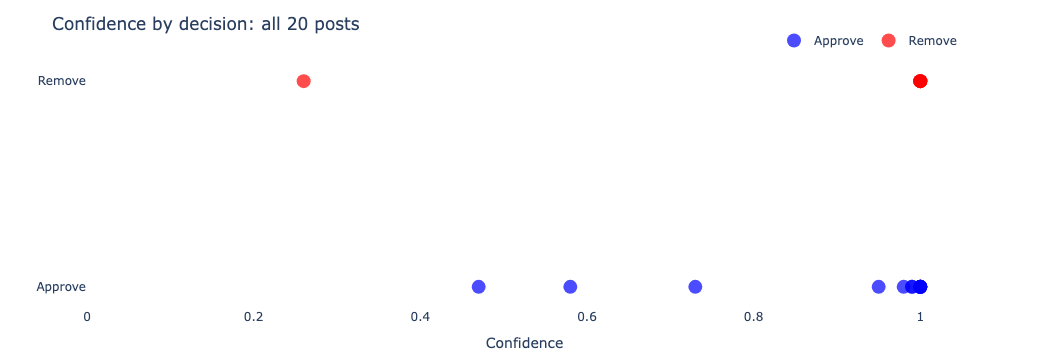

In [14]:
fig4 = go.Figure()

colors = {"Approve": "blue", "Flag": "orange", "Remove": "red"}

for decision, color in colors.items():
    subset = results_df[results_df["decision"] == decision]
    if subset.empty:
        continue
    fig4.add_trace(go.Scatter(
        x=subset["confidence"],
        y=subset["decision"],
        mode="markers",
        name=decision,
        marker=dict(color=color, size=14, opacity=0.7),
        text=subset["id"] + "<br>" + subset["band"],
        hoverinfo="text+x",
    ))

fig4.update_layout(
    title="Confidence by decision: all 20 posts",
    xaxis_title="Confidence",
    xaxis=dict(range=[0, 1.05]),
    yaxis_title="",
    plot_bgcolor="white",
    paper_bgcolor="white",
    font=dict(size=12),
    margin=dict(t=60, b=40),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
)
fig4.show()

## 12. Latency

In [15]:
print(f"Mean: {results_df['elapsed_ms'].mean():.0f}ms")
print(f"Min:  {results_df['elapsed_ms'].min():.0f}ms")
print(f"Max:  {results_df['elapsed_ms'].max():.0f}ms")

Mean: 247ms
Min:  196ms
Max:  392ms


## 13. Summary

One `Choice` call per post, three options, calibrated confidence. The three-option structure matters: it gives Jev somewhere to put genuine uncertainty without forcing a binary decision. The low-confidence posts flagged above are the ones that most need a human moderator's judgment, and the confidence score identifies them automatically.

A production implementation would route decisions by both outcome and confidence: high-confidence Remove goes straight to deletion, high-confidence Approve goes straight to publication, and anything below a confidence threshold -- regardless of which option Jev chose -- joins the human review queue. This is more honest than a binary classifier that always makes a decision with apparent certainty.